In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
dataset=pd.read_csv("ipl.csv")

In [3]:
dataset

,id,season,date,city,venue,team1,team2,toss_winner,toss_decision,dl_applied,...,nrr_diff,team1_overall_winrate,team2_overall_winrate,winrate_diff,team1_recent_form,team2_recent_form,form_diff,h2h_winrate,venue_winrate_diff,team1_won
0,60,2008,2008-04-18,Bangalore,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,0,...,0.00,0.5000,0.5000,0.0000,0.5,0.5,0.0,0.5000,0.0000,1
1,62,2008,2008-04-19,Delhi,Feroz Shah Kotla,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,0,...,0.00,0.5000,0.5000,0.0000,0.5,0.5,0.0,0.5000,0.0000,0
2,61,2008,2008-04-19,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,0,...,0.00,0.5000,0.5000,0.0000,0.5,0.5,0.0,0.5000,0.0000,1
3,64,2008,2008-04-20,Kolkata,Eden Gardens,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,0,...,0.00,0.5000,1.0000,-0.5000,0.5,1.0,-0.5,0.5000,0.0000,0
4,63,2008,2008-04-20,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,0,...,0.00,0.5000,0.0000,0.5000,0.5,0.0,0.5,0.5000,0.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621,55,2017,2017-05-14,Delhi,Feroz Shah Kotla,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,0,...,0.72,0.4830,0.4336,0.0494,0.0,0.8,-0.8,0.6250,0.2407,1
622,56,2017,2017-05-16,Mumbai,Wankhede Stadium,Rising Pune Supergiant,Mumbai Indians,Mumbai Indians,field,0,...,-0.44,0.6429,0.5817,0.0612,0.8,0.6,0.2,1.0000,0.3462,1
623,57,2017,2017-05-17,Bangalore,M Chinnaswamy Stadium,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,1,...,0.59,0.5541,0.5278,0.0263,0.6,0.2,0.4,0.3636,-0.1556,0
624,58,2017,2017-05-19,Bangalore,M Chinnaswamy Stadium,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,0,...,-0.32,0.5310,0.5779,-0.0469,0.4,0.4,0.0,0.2500,-0.1778,0


In [4]:
quan=dataset.select_dtypes(include=["int64",'float64']).columns

In [5]:
quan

Index(['id', 'season', 'dl_applied', 'win_by_runs', 'win_by_wickets',
       'team1_won_toss', 'bat_first', 'match_month', 'match_dayofweek',
       'match_no_in_season', 'team1_home', 'team2_home', 'team1_bat_sr',
       'team2_bat_sr', 'diff_bat_sr', 'team1_bat_avg', 'team2_bat_avg',
       'diff_bat_avg', 'team1_key_bat_avg', 'team2_key_bat_avg',
       'diff_key_bat_avg', 'team1_bowl_econ', 'team2_bowl_econ',
       'diff_bowl_econ', 'team1_bowl_sr', 'team2_bowl_sr', 'diff_bowl_sr',
       'team1_key_bowl_econ', 'team2_key_bowl_econ', 'diff_key_bowl_econ',
       'team1_prev_nrr', 'team2_prev_nrr', 'nrr_diff', 'team1_overall_winrate',
       'team2_overall_winrate', 'winrate_diff', 'team1_recent_form',
       'team2_recent_form', 'form_diff', 'h2h_winrate', 'venue_winrate_diff',
       'team1_won'],
      dtype='str')

In [6]:
qual=dataset.select_dtypes(include=["object"]).columns

C:\Users\achu3\AppData\Local\Temp\ipykernel_4956\1600036628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qual=dataset.select_dtypes(include=["object"]).columns


In [7]:
qual

Index(['date', 'city', 'venue', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'winner', 'player_of_match'],
      dtype='str')

In [8]:
dataset.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets,team1_won_toss,bat_first,match_month,match_dayofweek,match_no_in_season,...,nrr_diff,team1_overall_winrate,team2_overall_winrate,winrate_diff,team1_recent_form,team2_recent_form,form_diff,h2h_winrate,venue_winrate_diff,team1_won
count,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.0,626.000000,626.000000,626.000000,...,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000
mean,317.886581,2012.479233,0.025559,13.900958,3.426518,0.429712,1.0,4.450479,3.439297,32.207668,...,0.017859,0.509710,0.503559,0.006154,0.505644,0.498269,0.007375,0.511497,0.008101,0.448882
std,183.756025,2.777115,0.157942,24.036168,3.420671,0.495431,0.0,0.586467,2.022352,18.813570,...,0.429655,0.126071,0.124339,0.176550,0.235461,0.239173,0.339163,0.253429,0.404073,0.497778
min,1.000000,2008.000000,0.000000,0.000000,0.000000,0.000000,1.0,3.000000,0.000000,1.000000,...,-1.160000,0.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000
25%,159.250000,2010.000000,0.000000,0.000000,0.000000,0.000000,1.0,4.000000,2.000000,16.000000,...,-0.287500,0.468100,0.461500,-0.072025,0.400000,0.400000,-0.200000,0.400000,-0.250000,0.000000
50%,317.500000,2012.000000,0.000000,0.000000,4.000000,0.000000,1.0,4.000000,4.000000,32.000000,...,0.000000,0.517200,0.508950,0.003200,0.600000,0.400000,0.000000,0.500000,0.000000,0.000000
75%,476.500000,2015.000000,0.000000,20.000000,7.000000,1.000000,1.0,5.000000,5.000000,47.000000,...,0.300000,0.571075,0.565775,0.090625,0.600000,0.600000,0.200000,0.611550,0.250000,1.000000
max,636.000000,2017.000000,1.000000,146.000000,10.000000,1.000000,1.0,6.000000,6.000000,74.000000,...,1.160000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)

for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    
    
    mode_val = dataset[columnName].mode()
    if not mode_val.empty:
        descriptive.loc["Mode",columnName]=mode_val.iloc[0]
    else:
        descriptive.loc["Mode",columnName]=None
    
    descriptive.loc["Q1:25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["Q2:50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["Q3:75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["Q4:100%",columnName]=dataset.describe()[columnName]["max"]
    
    descriptive.loc["IQR",columnName]=descriptive.loc["Q3:75%",columnName]-descriptive.loc["Q1:25%",columnName]
    descriptive.loc["1.5rule",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["Lesser",columnName]=descriptive.loc["Q1:25%",columnName]-descriptive.loc["1.5rule",columnName]
    descriptive.loc["Greater",columnName]=descriptive.loc["Q3:75%",columnName]+descriptive.loc["1.5rule",columnName]
    
    descriptive.loc["Min",columnName]=dataset[columnName].min()
    descriptive.loc["Max",columnName]=dataset[columnName].max()

In [10]:
descriptive

,id,season,dl_applied,win_by_runs,win_by_wickets,team1_won_toss,bat_first,match_month,match_dayofweek,match_no_in_season,...,nrr_diff,team1_overall_winrate,team2_overall_winrate,winrate_diff,team1_recent_form,team2_recent_form,form_diff,h2h_winrate,venue_winrate_diff,team1_won
Mean,317.886581,2012.479233,0.025559,13.900958,3.426518,0.429712,1.0,4.450479,3.439297,32.207668,...,0.017859,0.50971,0.503559,0.006154,0.505644,0.498269,0.007375,0.511497,0.008101,0.448882
Median,317.5,2012.0,0.0,0.0,4.0,0.0,1.0,4.0,4.0,32.0,...,0.0,0.5172,0.50895,0.0032,0.6,0.4,0.0,0.5,0.0,0.0
Mode,1,2012,0,0,0,0,1,5,6,1,...,0.0,0.5,0.5,0.0,0.4,0.4,0.0,0.5,0.0,0
Q1:25%,159.25,2010.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,16.0,...,-0.2875,0.4681,0.4615,-0.072025,0.4,0.4,-0.2,0.4,-0.25,0.0
Q2:50%,317.5,2012.0,0.0,0.0,4.0,0.0,1.0,4.0,4.0,32.0,...,0.0,0.5172,0.50895,0.0032,0.6,0.4,0.0,0.5,0.0,0.0
Q3:75%,476.5,2015.0,0.0,20.0,7.0,1.0,1.0,5.0,5.0,47.0,...,0.3,0.571075,0.565775,0.090625,0.6,0.6,0.2,0.61155,0.25,1.0
Q4:100%,636.0,2017.0,1.0,146.0,10.0,1.0,1.0,6.0,6.0,74.0,...,1.16,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
IQR,317.25,5.0,0.0,20.0,7.0,1.0,0.0,1.0,3.0,31.0,...,0.5875,0.102975,0.104275,0.16265,0.2,0.2,0.4,0.21155,0.5,1.0
1.5rule,475.875,7.5,0.0,30.0,10.5,1.5,0.0,1.5,4.5,46.5,...,0.88125,0.154462,0.156412,0.243975,0.3,0.3,0.6,0.317325,0.75,1.5
Lesser,-316.625,2002.5,0.0,-30.0,-10.5,-1.5,1.0,2.5,-2.5,-30.5,...,-1.16875,0.313638,0.305088,-0.316,0.1,0.1,-0.8,0.082675,-1.0,-1.5


In [11]:
lesser=[]
greater=[]
for columnName in quan:
    if(descriptive.loc["Lesser"][columnName]>descriptive.loc["Min"][columnName]):
        lesser.append(columnName)
    if(descriptive.loc["Greater"][columnName]<descriptive.loc["Max"][columnName]):
        greater.append(columnName)

In [12]:
lesser

['diff_bat_sr',
 'diff_bat_avg',
 'diff_key_bat_avg',
 'diff_bowl_econ',
 'diff_key_bowl_econ',
 'team1_overall_winrate',
 'team2_overall_winrate',
 'winrate_diff',
 'team1_recent_form',
 'team2_recent_form',
 'form_diff',
 'h2h_winrate']

In [13]:
greater

['dl_applied',
 'win_by_runs',
 'team1_bat_sr',
 'team2_bat_sr',
 'diff_bat_sr',
 'team1_bat_avg',
 'team2_bat_avg',
 'diff_bat_avg',
 'team1_key_bat_avg',
 'team2_key_bat_avg',
 'diff_key_bat_avg',
 'diff_bowl_econ',
 'diff_key_bowl_econ',
 'team1_overall_winrate',
 'team2_overall_winrate',
 'winrate_diff',
 'team1_recent_form',
 'team2_recent_form',
 'form_diff',
 'h2h_winrate']

In [14]:
for columnName in lesser:
    dataset.loc[dataset[columnName]<descriptive.loc["Lesser",columnName],columnName]=descriptive.loc["Lesser",columnName]
for columnName in greater:
    dataset.loc[dataset[columnName]>descriptive.loc["Greater",columnName],columnName]=descriptive.loc["Greater",columnName]

In [15]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)

for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    
    
    mode_val = dataset[columnName].mode()
    if not mode_val.empty:
        descriptive.loc["Mode",columnName]=mode_val.iloc[0]
    else:
        descriptive.loc["Mode",columnName]=None
    
    descriptive.loc["Q1:25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["Q2:50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["Q3:75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["Q4:100%",columnName]=dataset.describe()[columnName]["max"]
    
    descriptive.loc["IQR",columnName]=descriptive.loc["Q3:75%",columnName]-descriptive.loc["Q1:25%",columnName]
    descriptive.loc["1.5rule",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["Lesser",columnName]=descriptive.loc["Q1:25%",columnName]-descriptive.loc["1.5rule",columnName]
    descriptive.loc["Greater",columnName]=descriptive.loc["Q3:75%",columnName]+descriptive.loc["1.5rule",columnName]
    
    descriptive.loc["Min",columnName]=dataset[columnName].min()
    descriptive.loc["Max",columnName]=dataset[columnName].max()

In [16]:
descriptive

,id,season,dl_applied,win_by_runs,win_by_wickets,team1_won_toss,bat_first,match_month,match_dayofweek,match_no_in_season,...,nrr_diff,team1_overall_winrate,team2_overall_winrate,winrate_diff,team1_recent_form,team2_recent_form,form_diff,h2h_winrate,venue_winrate_diff,team1_won
Mean,317.886581,2012.479233,0.0,11.49361,3.426518,0.429712,1.0,4.450479,3.439297,32.207668,...,0.017859,0.510672,0.505271,0.006352,0.507082,0.499068,0.007375,0.511072,0.008101,0.448882
Median,317.5,2012.0,0.0,0.0,4.0,0.0,1.0,4.0,4.0,32.0,...,0.0,0.5172,0.50895,0.0032,0.6,0.4,0.0,0.5,0.0,0.0
Mode,1,2012,0,0,0,0,1,5,6,1,...,0.0,0.5,0.5,-0.316,0.4,0.4,0.0,0.5,0.0,0
Q1:25%,159.25,2010.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,16.0,...,-0.2875,0.4681,0.4615,-0.072025,0.4,0.4,-0.2,0.4,-0.25,0.0
Q2:50%,317.5,2012.0,0.0,0.0,4.0,0.0,1.0,4.0,4.0,32.0,...,0.0,0.5172,0.50895,0.0032,0.6,0.4,0.0,0.5,0.0,0.0
Q3:75%,476.5,2015.0,0.0,20.0,7.0,1.0,1.0,5.0,5.0,47.0,...,0.3,0.571075,0.565775,0.090625,0.6,0.6,0.2,0.61155,0.25,1.0
Q4:100%,636.0,2017.0,0.0,50.0,10.0,1.0,1.0,6.0,6.0,74.0,...,1.16,0.725537,0.722187,0.3346,0.9,0.9,0.8,0.928875,1.0,1.0
IQR,317.25,5.0,0.0,20.0,7.0,1.0,0.0,1.0,3.0,31.0,...,0.5875,0.102975,0.104275,0.16265,0.2,0.2,0.4,0.21155,0.5,1.0
1.5rule,475.875,7.5,0.0,30.0,10.5,1.5,0.0,1.5,4.5,46.5,...,0.88125,0.154462,0.156412,0.243975,0.3,0.3,0.6,0.317325,0.75,1.5
Lesser,-316.625,2002.5,0.0,-30.0,-10.5,-1.5,1.0,2.5,-2.5,-30.5,...,-1.16875,0.313638,0.305088,-0.316,0.1,0.1,-0.8,0.082675,-1.0,-1.5


In [17]:
lesser=[]
greater=[]
for columnName in quan:
    if(descriptive.loc["Lesser"][columnName]>descriptive.loc["Min"][columnName]):
        lesser.append(columnName)
    if(descriptive.loc["Greater"][columnName]<descriptive.loc["Max"][columnName]):
        greater.append(columnName)

In [18]:
lesser,greater

([], [])

In [19]:
dataset.isnull().sum()

id                       0
season                   0
date                     0
city                     0
venue                    0
team1                    0
team2                    0
toss_winner              0
toss_decision            0
dl_applied               0
result                   0
winner                   0
win_by_runs              0
win_by_wickets           0
player_of_match          0
team1_won_toss           0
bat_first                0
match_month              0
match_dayofweek          0
match_no_in_season       0
team1_home               0
team2_home               0
team1_bat_sr             0
team2_bat_sr             0
diff_bat_sr              0
team1_bat_avg            0
team2_bat_avg            0
diff_bat_avg             0
team1_key_bat_avg        0
team2_key_bat_avg        0
diff_key_bat_avg         0
team1_bowl_econ          0
team2_bowl_econ          0
diff_bowl_econ           0
team1_bowl_sr            0
team2_bowl_sr            0
diff_bowl_sr             0
t

In [20]:
dataset["winner"].unique()

<StringArray>
[      'Kolkata Knight Riders',            'Delhi Daredevils',
         'Chennai Super Kings', 'Royal Challengers Bangalore',
            'Rajasthan Royals',             'Kings XI Punjab',
             'Deccan Chargers',              'Mumbai Indians',
               'Pune Warriors',        'Kochi Tuskers Kerala',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant']
Length: 14, dtype: str

In [21]:
dataset["winner"]=dataset["winner"].replace("Rising Pune Supergiant","Rising Pune Supergiants")

In [22]:
dataset["winner"].unique()

<StringArray>
[      'Kolkata Knight Riders',            'Delhi Daredevils',
         'Chennai Super Kings', 'Royal Challengers Bangalore',
            'Rajasthan Royals',             'Kings XI Punjab',
             'Deccan Chargers',              'Mumbai Indians',
               'Pune Warriors',        'Kochi Tuskers Kerala',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions']
Length: 13, dtype: str

In [23]:
dataset["city"].unique()

<StringArray>
[     'Bangalore',          'Delhi',     'Chandigarh',        'Kolkata',
         'Mumbai',         'Jaipur',      'Hyderabad',        'Chennai',
      'Cape Town', 'Port Elizabeth',         'Durban',      'Centurion',
    'East London',   'Johannesburg',      'Kimberley',   'Bloemfontein',
      'Ahmedabad',        'Cuttack',         'Nagpur',     'Dharamsala',
          'Kochi',         'Indore',  'Visakhapatnam',           'Pune',
         'Raipur',         'Ranchi',      'Abu Dhabi',        'Sharjah',
        'Unknown',         'Rajkot',         'Kanpur']
Length: 31, dtype: str

In [24]:
dataset=dataset.drop(['date'],axis=1)

In [25]:
dataset.columns

Index(['id', 'season', 'city', 'venue', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'dl_applied', 'result', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'team1_won_toss', 'bat_first',
       'match_month', 'match_dayofweek', 'match_no_in_season', 'team1_home',
       'team2_home', 'team1_bat_sr', 'team2_bat_sr', 'diff_bat_sr',
       'team1_bat_avg', 'team2_bat_avg', 'diff_bat_avg', 'team1_key_bat_avg',
       'team2_key_bat_avg', 'diff_key_bat_avg', 'team1_bowl_econ',
       'team2_bowl_econ', 'diff_bowl_econ', 'team1_bowl_sr', 'team2_bowl_sr',
       'diff_bowl_sr', 'team1_key_bowl_econ', 'team2_key_bowl_econ',
       'diff_key_bowl_econ', 'team1_prev_nrr', 'team2_prev_nrr', 'nrr_diff',
       'team1_overall_winrate', 'team2_overall_winrate', 'winrate_diff',
       'team1_recent_form', 'team2_recent_form', 'form_diff', 'h2h_winrate',
       'venue_winrate_diff', 'team1_won'],
      dtype='str')

In [26]:
x = dataset[['city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision',
       'dl_applied', 'result', 'win_by_runs', 'win_by_wickets',
       'player_of_match', 'team1_won_toss', 'bat_first', 'team1_home',
       'team2_home', 'team1_bat_sr', 'team2_bat_sr', 'diff_bat_sr',
       'team1_bat_avg', 'team2_bat_avg', 'diff_bat_avg', 'team1_key_bat_avg',
       'team2_key_bat_avg', 'diff_key_bat_avg', 'team1_bowl_econ',
       'team2_bowl_econ', 'diff_bowl_econ', 'team1_bowl_sr', 'team2_bowl_sr',
       'diff_bowl_sr', 'team1_key_bowl_econ', 'team2_key_bowl_econ',
       'diff_key_bowl_econ', 'team1_prev_nrr', 'team2_prev_nrr', 'nrr_diff',
       'team1_overall_winrate', 'team2_overall_winrate', 'winrate_diff',
       'team1_recent_form', 'team2_recent_form', 'form_diff', 'h2h_winrate',
       'venue_winrate_diff', 'team1_won']]
y=dataset[["winner"]]

In [27]:
from sklearn.preprocessing import LabelEncoder

# List of categorical columns
cat_cols = ['city', 'venue', 'team1', 'team2', 
            'toss_winner', 'toss_decision', 
            'result', 'player_of_match']

# Create a dictionary to store encoders (optional but useful)
label_encoders = {}

# Apply Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col].astype(str))  # convert to string to avoid issues
    label_encoders[col] = le  # store encoder if you need inverse transform later

In [28]:
x

,city,venue,team1,team2,toss_winner,toss_decision,dl_applied,result,win_by_runs,win_by_wickets,...,nrr_diff,team1_overall_winrate,team2_overall_winrate,winrate_diff,team1_recent_form,team2_recent_form,form_diff,h2h_winrate,venue_winrate_diff,team1_won
0,2,14,6,12,12,1,0,0,50,0,...,0.00,0.5000,0.500000,0.0000,0.5,0.5,0.0,0.500000,0.0000,1
1,9,8,9,2,9,0,0,0,0,9,...,0.00,0.5000,0.500000,0.0000,0.5,0.5,0.0,0.500000,0.0000,0
2,6,22,0,4,0,0,0,0,33,0,...,0.00,0.5000,0.500000,0.0000,0.5,0.5,0.0,0.500000,0.0000,1
3,20,7,1,6,1,0,0,0,0,5,...,0.00,0.5000,0.722187,-0.3160,0.5,0.9,-0.5,0.500000,0.0000,0
4,21,34,7,12,7,0,0,0,0,5,...,0.00,0.5000,0.305088,0.3346,0.5,0.1,0.5,0.500000,0.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621,9,8,12,2,12,0,0,0,10,0,...,0.72,0.4830,0.433600,0.0494,0.1,0.8,-0.8,0.625000,0.2407,1
622,21,34,10,7,7,1,0,0,20,0,...,-0.44,0.6429,0.581700,0.0612,0.8,0.6,0.2,0.928875,0.3462,1
623,2,14,13,6,6,1,0,0,0,7,...,0.59,0.5541,0.527800,0.0263,0.6,0.2,0.4,0.363600,-0.1556,0
624,2,14,6,7,7,1,0,0,0,6,...,-0.32,0.5310,0.577900,-0.0469,0.4,0.4,0.0,0.250000,-0.1778,0


In [29]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y['winner'] = le.fit_transform(y['winner'])


In [30]:
type(x),type(y)

(pandas.DataFrame, pandas.DataFrame)

In [31]:
y['winner'].value_counts()

winner
7     91
0     79
6     77
11    72
4     68
2     62
9     61
12    41
1     29
10    15
3     13
8     12
5      6
Name: count, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.30,random_state=0)

In [33]:
y_train

,winner
338,12
392,7
508,10
378,7
618,12
...,...
277,1
9,4
359,12
192,5


In [34]:
from sklearn.feature_selection import SelectKBest, f_classif

def selectkbest(x, y, n):
    test = SelectKBest(score_func=f_classif, k=n)  # Changed: chi2 → f_classif
    fit1 = test.fit(x, y)
    sel_feat_values = fit1.transform(x)
    mask = fit1.get_support()
    selected_features = x.columns[mask].tolist()
    return sel_feat_values, selected_features
feature_values,selected_features = selectkbest(x, y, 30)
print(f"Selected Features: {selected_features}")

Selected Features: ['city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'player_of_match', 'team1_won_toss', 'team1_bat_sr', 'team2_bat_sr', 'team1_bat_avg', 'team2_bat_avg', 'diff_bat_avg', 'team1_key_bat_avg', 'team2_key_bat_avg', 'diff_key_bat_avg', 'team1_bowl_econ', 'team2_bowl_econ', 'team1_bowl_sr', 'team2_bowl_sr', 'team1_key_bowl_econ', 'team2_key_bowl_econ', 'team1_prev_nrr', 'team2_prev_nrr', 'team1_overall_winrate', 'team2_overall_winrate', 'winrate_diff', 'team1_recent_form', 'h2h_winrate', 'team1_won']


C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 6  7 12] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [35]:
def cm_prediction(classifier, x_test, y_test):

    from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

    y_pred = classifier.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)
    Accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    return classifier, Accuracy, report, x_test, y_test, cm

def logistic(x_train, y_train, x_test, y_test):       
        
        from sklearn.linear_model import LogisticRegression
        from sklearn.model_selection import GridSearchCV

        
        param_grid = {'C': [0.1, 1, 10],'solver': ['lbfgs'],'max_iter': [1000]}
        grid = GridSearchCV(LogisticRegression(random_state=0), param_grid, cv=3)
        grid.fit(x_train, y_train)
        classifier = grid.best_estimator_
        print("Best Parameters:", grid.best_params_)

       
        classifier, Accuracy, report, x_test, y_test, cm = cm_prediction(classifier, x_test, y_test)

        return classifier, Accuracy, report, x_test, y_test, cm
def svm_linear(x_train, y_train, x_test, y_test):
                
        from sklearn.svm import SVC
        from sklearn.model_selection import GridSearchCV

        param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear']
        }

        grid = GridSearchCV(SVC(random_state=0), param_grid, cv=3)
        grid.fit(x_train, y_train)

        classifier = grid.best_estimator_

        print("SVM Best:", grid.best_params_)

        classifier, Accuracy, report, x_test, y_test, cm = cm_prediction(classifier, x_test, y_test)

        return classifier, Accuracy, report, x_test, y_test, cm
def Decision(x_train, y_train, x_test, y_test):
        
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.model_selection import GridSearchCV

        param_grid = {
            'criterion': ['gini', 'entropy'],
            'max_depth': [5, 10, 20]
        }

        grid = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=3)
        grid.fit(x_train, y_train)

        classifier = grid.best_estimator_

        print("Decision Best:", grid.best_params_)

        classifier, Accuracy, report, x_test, y_test, cm = cm_prediction(classifier, x_test, y_test)

        return classifier, Accuracy, report, x_test, y_test, cm
def random(x_train, y_train, x_test, y_test):
        
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import GridSearchCV

        param_grid = {
            'n_estimators': [100, 200],
            'criterion': ['gini', 'entropy']
        }

        grid = GridSearchCV(RandomForestClassifier(random_state=0), param_grid, cv=3)
        grid.fit(x_train, y_train)

        classifier = grid.best_estimator_

        print("RF Best:", grid.best_params_)

        classifier, Accuracy, report, x_test, y_test, cm = cm_prediction(classifier, x_test, y_test)

        return classifier, Accuracy, report, x_test, y_test, cm




In [36]:
def selectk_Classification(acclog,accsvml,accdes,accrf): 
    dataframe=pd.DataFrame(index=['ChiSquare'],columns=['Logistic','SVMl','Decision','Random'])
    for number,idex in enumerate(dataframe.index):      
        dataframe.loc[idex,'Logistic'] = acclog[number]
        dataframe.loc[idex,'SVMl'] = accsvml[number]
        dataframe.loc[idex,'Decision'] = accdes[number]
        dataframe.loc[idex,'Random'] = accrf[number]
    return dataframe

In [37]:
acclog=[]
accsvml=[]
accdes=[]
accrf=[]

In [38]:
x_train, x_test, y_train, y_test=train_test_split(feature_values,y,test_size=0.30,random_state=0)
    
        
classifier, Accuracy, report, x_test, y_test, cm = svm_linear(x_train, y_train, x_test, y_test)
acclog.append(Accuracy)

classifier,Accuracy,report,x_test,y_test,cm=svm_linear(x_train,y_train,x_test,y_test)  
accsvml.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=Decision(x_train,y_train,x_test,y_test)  
accdes.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=random(x_train,y_train,x_test,y_test)  
accrf.append(Accuracy)
    
result=selectk_Classification(acclog,accsvml,accdes,accrf)

result

C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for 

SVM Best: {'C': 10, 'kernel': 'linear'}


C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for 

SVM Best: {'C': 10, 'kernel': 'linear'}
Decision Best: {'criterion': 'entropy', 'max_depth': 10}


C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example

RF Best: {'criterion': 'entropy', 'n_estimators': 100}


,Logistic,SVMl,Decision,Random
ChiSquare,0.430851,0.430851,0.829787,0.696809


In [39]:
import matplotlib.pyplot as plt

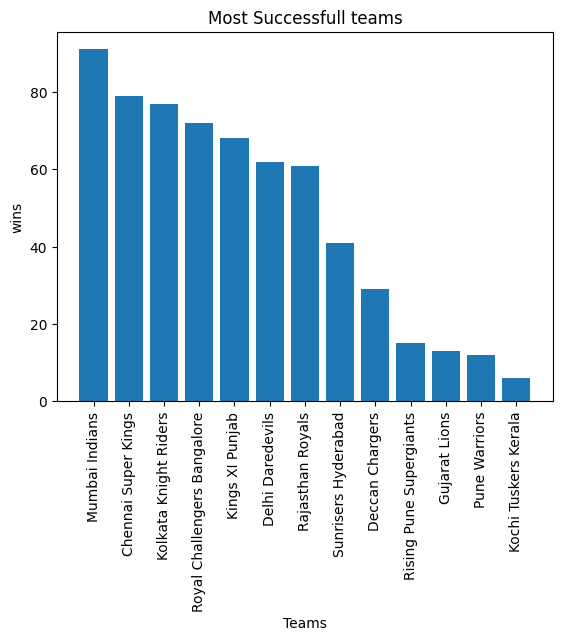

In [40]:
team_wins = dataset["winner"].value_counts()
plt.bar(team_wins.index, team_wins.values)
plt.xticks(rotation=90)
plt.xlabel("Teams")
plt.ylabel("wins")
plt.title("Most Successfull teams")
plt.show()

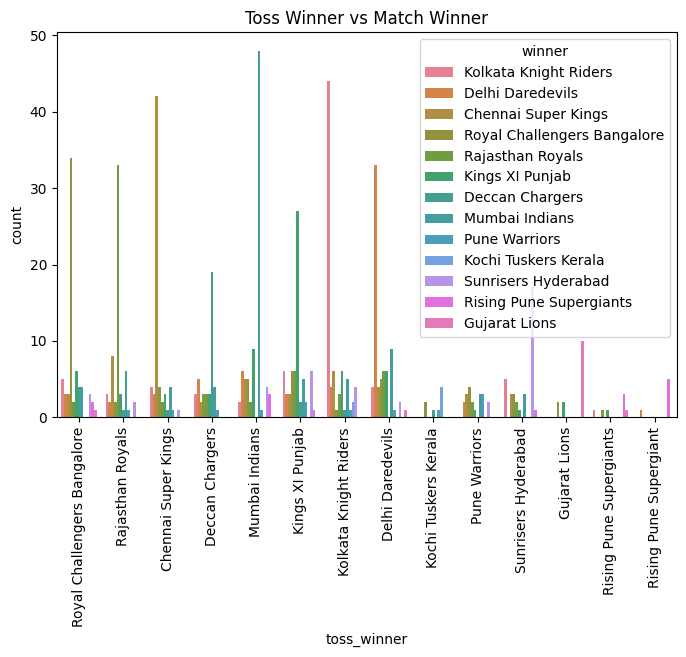

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x='toss_winner', hue='winner', data=dataset)
plt.xticks(rotation=90)
plt.title("Toss Winner vs Match Winner")
plt.show()

In [53]:
feature_values, selected_features = selectkbest(x, y, 30)
print("Selected Features:", selected_features)

Selected Features: ['city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'player_of_match', 'team1_won_toss', 'team1_bat_sr', 'team2_bat_sr', 'team1_bat_avg', 'team2_bat_avg', 'diff_bat_avg', 'team1_key_bat_avg', 'team2_key_bat_avg', 'diff_key_bat_avg', 'team1_bowl_econ', 'team2_bowl_econ', 'team1_bowl_sr', 'team2_bowl_sr', 'team1_key_bowl_econ', 'team2_key_bowl_econ', 'team1_prev_nrr', 'team2_prev_nrr', 'team1_overall_winrate', 'team2_overall_winrate', 'winrate_diff', 'team1_recent_form', 'h2h_winrate', 'team1_won']


C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 6  7 12] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [54]:
x_selected = x[selected_features]

In [55]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_selected, y, test_size=0.3, random_state=0
)

In [56]:
classifier, Accuracy, report, x_test, y_test, cm = Decision(
    x_train, y_train, x_test, y_test
)

print("Final Accuracy:", Accuracy)

Decision Best: {'criterion': 'entropy', 'max_depth': 10}
Final Accuracy: 0.8297872340425532


In [65]:
import pickle

pickle.dump({
    "model": classifier,
    "columns": x.columns,
    "encoders": label_encoders
}, open("final.sav", "wb"))

In [66]:
data = pickle.load(open("final.sav", "rb"))

model = data["model"]
columns = data["columns"]
encoders = data["encoders"]